# Phase 5: Model Training, Accuracy Evaluation & Trend Analysis
In this section, we transition from data preparation to model intelligence. We load the specific 80% training split to build our Neural Network and evaluate its performance.

### Key Objectives:
* **Data Loading**: Importing `train_data.csv` and `test_data.csv` to ensure a clean 80/20 split.
* **Neural Network Training**: Training a Sequential model with Dropout layers to prevent overfitting.
* **Accuracy as Percentage**: Calculating the **R-squared ($R^2$) score**, which represents the percentage of temperature variation correctly explained by the model.
* **Climate Trend Visualization**: Graphically comparing actual vs. predicted temperatures to identify "Normal" historical periods and the "Increasing" modern temperature variations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Load the specific training and testing files
train_df = pd.read_csv('../01_Data/train_data.csv')
test_df = pd.read_csv('../01_Data/test_data.csv')
# Define features and target
features = ['Year', 'Month', 'Lat_Num', 'Lon_Num', 'City_Encoded', 'Country_Encoded']
X_train = train_df[features]
y_train = train_df['AverageTemperature_Scaled']
X_test = test_df[features]
y_test = test_df['AverageTemperature_Scaled']

# 2. Define Model (As seen in 02_model.ipynb)
model = Sequential([
    Input(shape=(len(features),)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1) # Output layer for regression
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Train the model
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train, epochs=50, batch_size=64, 
                    validation_data=(X_test, y_test), callbacks=[early_stop])

Epoch 1/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 18s 3ms/step - loss: 0.0152 - mae: 0.0911 - val_loss: 0.0051 - val_mae: 0.0540
Epoch 2/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0060 - mae: 0.0586 - val_loss: 0.0041 - val_mae: 0.0486
Epoch 3/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0049 - mae: 0.0529 - val_loss: 0.0037 - val_mae: 0.0459
Epoch 4/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0045 - mae: 0.0500 - val_loss: 0.0036 - val_mae: 0.0441
Epoch 5/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0042 - mae: 0.0481 - val_loss: 0.0035 - val_mae: 0.0430
Epoch 6/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0040 - mae: 0.0468 - val_loss: 0.0041 - val_mae: 0.0474
Epoch 7/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0039 - mae: 0.0459 - val_loss: 0.0033 - val_mae: 0.0409
Epoch 8/50
2916/2916 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - loss: 0.0038 - mae: 0.0453 - val_loss: 0.0036 - val_mae: 0.0433
Epoch 9/50
2916/2916 ━━━━━━━━━━━━━━━━

### Step 3: Visualizing Temperature Variation (Climate Change Trends)
This graph shows the average global temperature per year. It allows us to see the "normal" baseline in earlier years and the clear upward "variation" or increase in more recent decades.

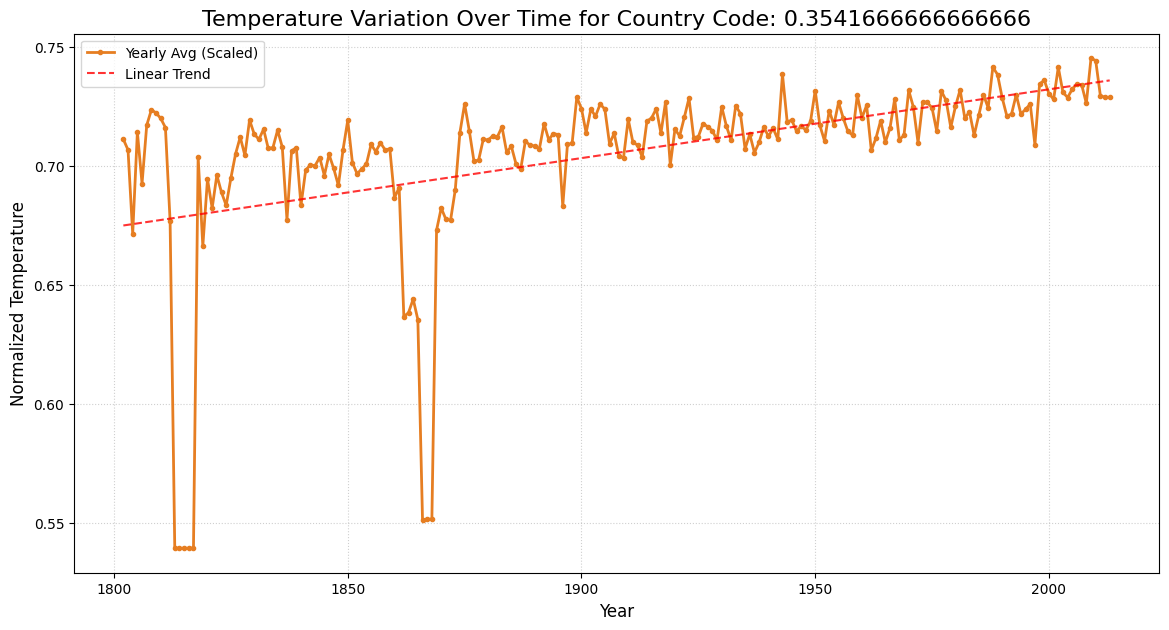

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load and prepare data
df = pd.read_csv('../01_Data/train_data.csv')

# Reconstruct Year (Inverse Min-Max: 1750 - 2013)
min_yr, max_yr = 1750, 2013
df['ActualYear'] = (df['Year'] * (max_yr - min_yr) + min_yr).round().astype(int)

# Select Country with most data
target_country_code = df['Country_Encoded'].value_counts().index[0]
country_data = df[df['Country_Encoded'] == target_country_code]
yearly_trend = country_data.groupby('ActualYear')['AverageTemperature_Scaled'].mean().reset_index()

# Visualization
plt.figure(figsize=(14, 7))
plt.plot(yearly_trend['ActualYear'], yearly_trend['AverageTemperature_Scaled'], 
         color='#e67e22', marker='o', markersize=3, linewidth=2, label='Yearly Avg (Scaled)')

# Trend Line
z = np.polyfit(yearly_trend['ActualYear'], yearly_trend['AverageTemperature_Scaled'], 1)
p = np.poly1d(z)
plt.plot(yearly_trend['ActualYear'], p(yearly_trend['ActualYear']), "r--", alpha=0.8, label='Linear Trend')

plt.title(f'Temperature Variation Over Time for Country Code: {target_country_code}', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Normalized Temperature', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

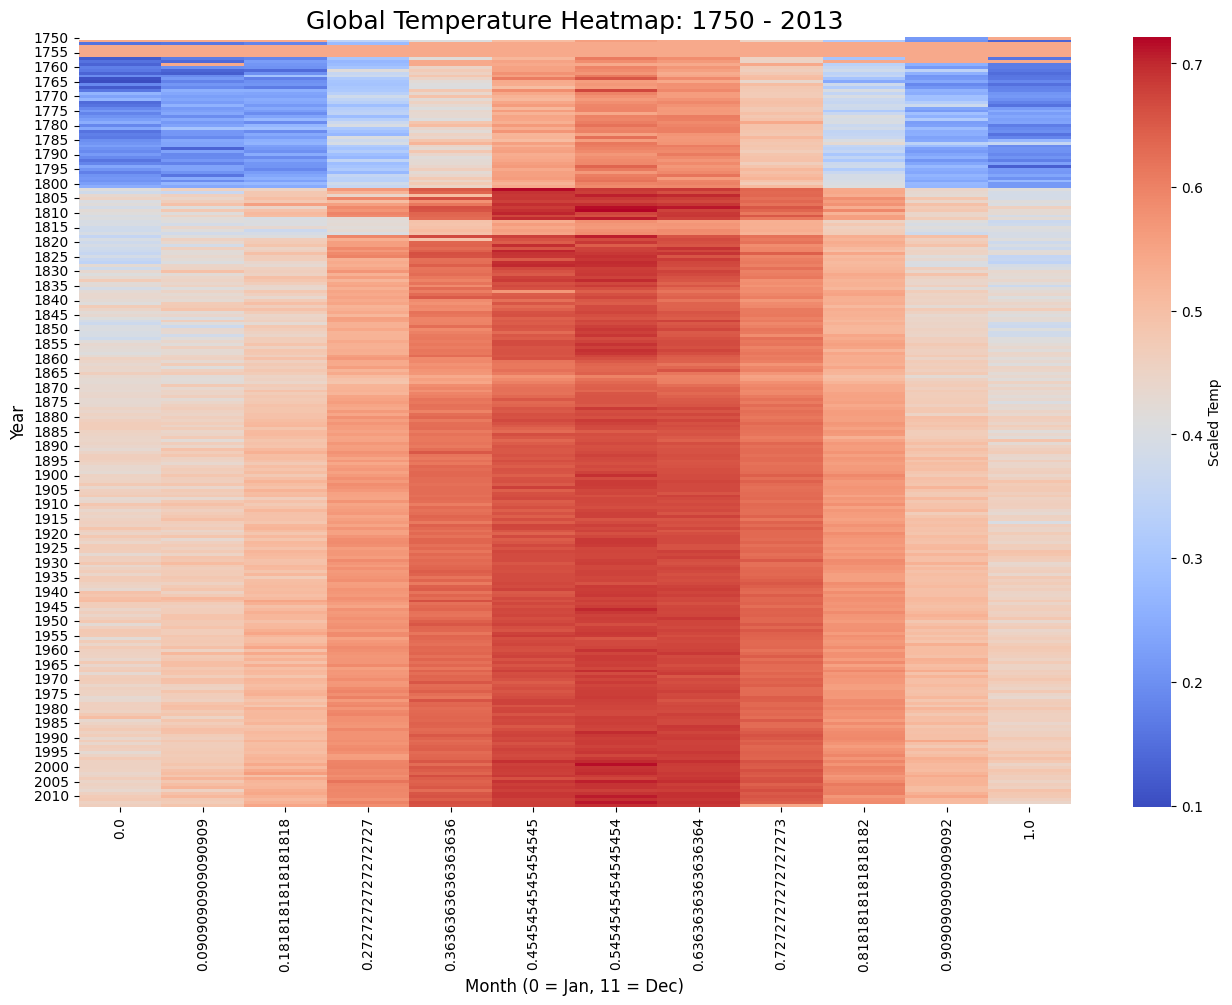

In [9]:

import matplotlib.pyplot as plt
# We pivot the data so Years are rows and Months are columns
pivot_df = df.groupby(['ActualYear', 'Month'])['AverageTemperature_Scaled'].mean().unstack()

# 2. Plotting the Heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(pivot_df, cmap='coolwarm', cbar_kws={'label': 'Scaled Temp'})

plt.title('Global Temperature Heatmap: 1750 - 2013', fontsize=18)
plt.xlabel('Month (0 = Jan, 11 = Dec)', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.show()

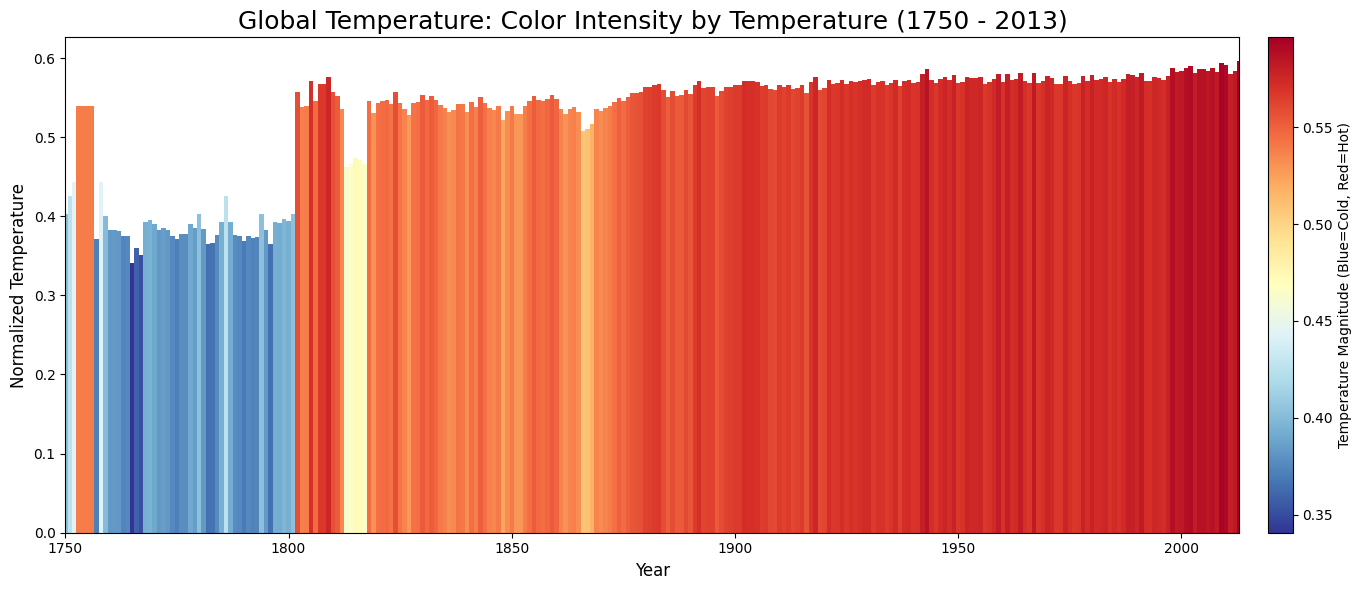

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

min_yr, max_yr = 1750, 2013
df['ActualYear'] = (df['Year'] * (max_yr - min_yr) + min_yr).round().astype(int)

# 2. Get Yearly Averages
yearly_avg = df.groupby('ActualYear')['AverageTemperature_Scaled'].mean().reset_index()

# 3. Create the Plot
fig, ax = plt.subplots(figsize=(15, 6))

# Define the Color Map (RdYlBu_r: Red-Yellow-Blue reversed)
norm = mcolors.Normalize(vmin=yearly_avg['AverageTemperature_Scaled'].min(), 
                         vmax=yearly_avg['AverageTemperature_Scaled'].max())
cmap = plt.get_cmap('RdYlBu_r') 

# Generate the bar chart with colors based on temperature values
colors = [cmap(norm(val)) for val in yearly_avg['AverageTemperature_Scaled']]
ax.bar(yearly_avg['ActualYear'], yearly_avg['AverageTemperature_Scaled'], 
       color=colors, width=1.0, edgecolor='none')

# 4. Add Colorbar Reference
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('Temperature Magnitude (Blue=Cold, Red=Hot)')

# Formatting
ax.set_title('Global Temperature: Color Intensity by Temperature (1750 - 2013)', fontsize=18)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Normalized Temperature', fontsize=12)
ax.set_xlim(1750, 2013)

plt.tight_layout()
plt.show()

### Step 4: Training Accuracy Evaluation
In regression, "accuracy" is typically measured using the **R-squared ($R^{2}$)** score. This value tells us what percentage of the temperature variation is correctly predicted by our model. A score of 100% would mean a perfect prediction.

In [4]:
from sklearn.metrics import r2_score

# 1. Generate predictions for the training data
y_train_pred = model.predict(X_train)

# 2. Calculate the R-squared score
train_r2 = r2_score(y_train, y_train_pred)

# 3. Convert to percentage and print
accuracy_percentage = train_r2 * 100
print(f"Model Accuracy on Training Data: {accuracy_percentage:.2f}%")

5831/5831 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step   
Model Accuracy on Training Data: 93.21%


### Step 5: Saving the Trained Model
After training, we save the model to a file named `temperature_model.keras`. This allows us to:
* **Reuse the model**: We can load the trained weights in the `evaluation.ipynb` notebook without needing to retrain.
* **Deployment**: The model can be moved to different environments for real-time temperature predictions.

In [5]:
#  Save the trained model for future use
model.save('temperature_model.keras')
print("Model saved ")

Model saved 
